# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision.transforms as T

C:\ProgramData\anaconda3\Lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


# Network Architecture

In [2]:
class EmbeddingNet(nn.Module):
    def __init__(self):
        super(EmbeddingNet, self).__init__()
        self.convnet = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 320x320

            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 160x160

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 80x80

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 40x40

            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.fc = nn.Linear(512, 128)

    def forward(self, x):
        x = self.convnet(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)  # batch_size, 128)
        return x

In [3]:
class TripletNet(nn.Module):
    def __init__(self, embedding_net):
        super(TripletNet, self).__init__()
        self.embedding_net = embedding_net

    def forward(self, anchor, positive, negative):
        anchor_out = self.embedding_net(anchor)
        positive_out = self.embedding_net(positive)
        negative_out = self.embedding_net(negative)
        return anchor_out, positive_out, negative_out

In [4]:
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        d_positive = F.pairwise_distance(anchor, positive, p=2)
        d_negative = F.pairwise_distance(anchor, negative, p=2)
        loss = F.relu(d_positive - d_negative + self.margin)
        return loss.mean()

# Dataset Design

In [5]:
class ImageTripletDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.anchor_dir = os.path.join(root_dir, "anchor")
        self.positive_dir = os.path.join(root_dir, "positive")
        self.negative_dir = os.path.join(root_dir, "negative")

        self.filenames = sorted(os.listdir(self.anchor_dir))
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        anchor_path = os.path.join(self.anchor_dir, self.filenames[idx])
        positive_path = os.path.join(self.positive_dir, self.filenames[idx])
        negative_path = os.path.join(self.negative_dir, self.filenames[idx])

        anchor = Image.open(anchor_path).convert("RGB")
        positive = Image.open(positive_path).convert("RGB")
        negative = Image.open(negative_path).convert("RGB")

        if self.transform:
            anchor = self.transform(anchor)
            positive = self.transform(positive)
            negative = self.transform(negative)

        return anchor, positive, negative

In [6]:
transform = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])

dataset = ImageTripletDataset(root_dir="triplet_data", transform=transform)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

# Training Loop

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

embedding_net = EmbeddingNet()
model = TripletNet(embedding_net).to(device)

triplet_loss = nn.TripletMarginLoss(margin=1.0, p=2)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [8]:
from torchsummary import summary

print("Summary for EmbeddingNet:")
embedding_net_instance = EmbeddingNet().to(device)
summary(embedding_net_instance, (3, 640, 640), device=str(device))

Summary for EmbeddingNet:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 640, 640]           2,432
              ReLU-2         [-1, 32, 640, 640]               0
         MaxPool2d-3         [-1, 32, 320, 320]               0
            Conv2d-4         [-1, 64, 320, 320]          51,264
              ReLU-5         [-1, 64, 320, 320]               0
         MaxPool2d-6         [-1, 64, 160, 160]               0
            Conv2d-7        [-1, 128, 160, 160]          73,856
              ReLU-8        [-1, 128, 160, 160]               0
         MaxPool2d-9          [-1, 128, 80, 80]               0
           Conv2d-10          [-1, 256, 80, 80]         295,168
             ReLU-11          [-1, 256, 80, 80]               0
        MaxPool2d-12          [-1, 256, 40, 40]               0
           Conv2d-13          [-1, 512, 40, 40]       1,180,160
             

In [9]:
import torch.optim.lr_scheduler as lr_scheduler

num_epochs = 64
loss_result = []

scheduler = lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for anchor, positive, negative in loader:
        anchor = anchor.to(device)
        positive = positive.to(device)
        negative = negative.to(device)

        optimizer.zero_grad()
        anchor_out, positive_out, negative_out = model(anchor, positive, negative)

        loss = triplet_loss(anchor_out, positive_out, negative_out)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    loss_result.append(avg_loss)

    scheduler.step()

    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.8f} - LR: {optimizer.param_groups[0]['lr']:.8f}")


C:\Users\pouri\AppData\Roaming\Python\Python311\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/64] - Loss: 0.71268469 - LR: 0.00100000
Epoch [2/64] - Loss: 0.39346718 - LR: 0.00100000
Epoch [3/64] - Loss: 0.32766057 - LR: 0.00100000
Epoch [4/64] - Loss: 0.27206845 - LR: 0.00050000
Epoch [5/64] - Loss: 0.20331681 - LR: 0.00050000
Epoch [6/64] - Loss: 0.15369344 - LR: 0.00050000
Epoch [7/64] - Loss: 0.16955774 - LR: 0.00050000
Epoch [8/64] - Loss: 0.11752872 - LR: 0.00025000
Epoch [9/64] - Loss: 0.11117408 - LR: 0.00025000
Epoch [10/64] - Loss: 0.08508955 - LR: 0.00025000
Epoch [11/64] - Loss: 0.07254803 - LR: 0.00025000
Epoch [12/64] - Loss: 0.04490835 - LR: 0.00012500
Epoch [13/64] - Loss: 0.06689983 - LR: 0.00012500
Epoch [14/64] - Loss: 0.05031902 - LR: 0.00012500
Epoch [15/64] - Loss: 0.05518019 - LR: 0.00012500
Epoch [16/64] - Loss: 0.04900388 - LR: 0.00006250
Epoch [17/64] - Loss: 0.03807207 - LR: 0.00006250
Epoch [18/64] - Loss: 0.02859394 - LR: 0.00006250
Epoch [19/64] - Loss: 0.02710654 - LR: 0.00006250
Epoch [20/64] - Loss: 0.02995921 - LR: 0.00003125
Epoch [21

# Plot the result

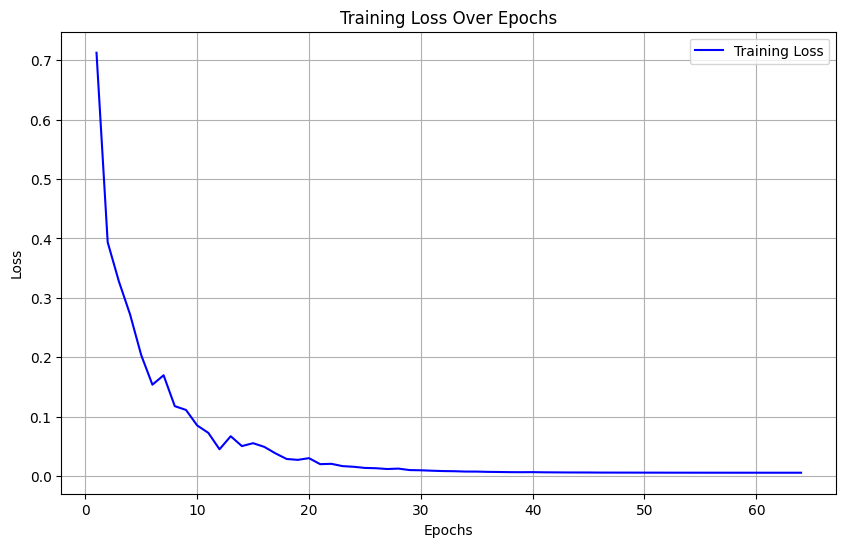

In [13]:
epochs = range(1, len(loss_result) + 1)

plt.figure(figsize=(10, 6))

plt.plot(epochs, loss_result, 'b', label='Training Loss')


plt.title('Training Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


plt.show()

plt.savefig('loss_curve.png')
plt.close()

# Evaluation

In [23]:
def evaluate_anchor(anchor_path, positive_dir, negative_dir, model, device="cuda"):
    model = model.to(device)
    model.eval()

    anchor_img = Image.open(anchor_path).convert("RGB")
    anchor_tensor = transform(anchor_img).unsqueeze(0).to(device)
    with torch.no_grad():
        anchor_embed = model(anchor_tensor)

    def compute_distances(img_dir):
        distances = []
        for fname in os.listdir(img_dir):
            fpath = os.path.join(img_dir, fname)
            if not os.path.isfile(fpath):
                continue
            img = Image.open(fpath).convert("RGB")
            img_tensor = transform(img).unsqueeze(0).to(device)
            with torch.no_grad():
                embed = model(img_tensor)
                dist = F.pairwise_distance(anchor_embed, embed).item()
                distances.append(dist)
        return distances

    pos_distances = compute_distances(positive_dir)
    neg_distances = compute_distances(negative_dir)

    results = {
        "positive": {
            "min": np.min(pos_distances) if pos_distances else None,
            "max": np.max(pos_distances) if pos_distances else None,
            "mean": np.mean(pos_distances) if pos_distances else None,
        },
        "negative": {
            "min": np.min(neg_distances) if neg_distances else None,
            "max": np.max(neg_distances) if neg_distances else None,
            "mean": np.mean(neg_distances) if neg_distances else None,
        },
    }

    return results


anchor_path = "triplet_data/anchor/2.jpg"
positive_dir = "triplet_data/positive"
negative_dir = "triplet_data/negative"

results = evaluate_anchor(anchor_path, positive_dir, negative_dir, embedding_net)
print("Positive distances:", results["positive"])
print("Negative distances:", results["negative"])

Positive distances: {'min': 1.1313708455418237e-05, 'max': 4.511295318603516, 'mean': 1.331603182368035}
Negative distances: {'min': 1.3420835733413696, 'max': 22.7416934967041, 'mean': 7.355673738718033}


# Save the model

In [21]:
torch.save(embedding_net.state_dict(), "embedding_net.pth")